In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('twitter_training.csv', header=None, names=['ID', 'Topic', 'Sentiment', 'Text'])
df = df.dropna(subset=['Sentiment', 'Text'])

print(f"Dataset loaded with {len(df)} rows.")
print(df.head(10))

Dataset loaded with 73996 rows.
     ID        Topic Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   
5  2401  Borderlands  Positive   
6  2402  Borderlands  Positive   
7  2402  Borderlands  Positive   
8  2402  Borderlands  Positive   
9  2402  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
5  im getting into borderlands and i can murder y...  
6  So I spent a few hours making something for fu...  
7  So I spent a couple of hours doing something f...  
8  So I spent a few hours doing something for fun...  
9  So I spent a few hours making something 

In [11]:
pos_words = {'love', 'good', 'great', 'amazing', 'best', 'happy', 'win', 'excellent', 'fun'}
neg_words = {'bad', 'hate', 'worst', 'terrible', 'fail', 'broken', 'sucks', 'fix', 'trash'}

def get_lexicon_score(text):
    words = set(str(text).lower().split())
    score = len(words.intersection(pos_words)) - len(words.intersection(neg_words))
    return score

df['Lexicon_Score'] = df['Text'].apply(get_lexicon_score)
print("Lexicon (Dictionary-based) features generated!")
df[['Text', 'Lexicon_Score']].head()

Lexicon (Dictionary-based) features generated!


,Text,Lexicon_Score
0,im getting on borderlands and i will murder yo...,0
1,I am coming to the borders and I will kill you...,0
2,im getting on borderlands and i will kill you ...,0
3,im coming on borderlands and i will murder you...,0
4,im getting on borderlands 2 and i will murder ...,0


In [12]:
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['Text']).toarray()

print(f"Text converted to a matrix of shape: {X_tfidf.shape}")

Text converted to a matrix of shape: (73996, 2000)


In [13]:
X_hybrid = np.hstack((X_tfidf, df[['Lexicon_Score']].values))
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X_hybrid, y, test_size=0.2, random_state=42)
print("Hybrid features combined and data split successfully!")

Hybrid features combined and data split successfully!


In [15]:
hybrid_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
hybrid_model.fit(X_train, y_train)
y_pred = hybrid_model.predict(X_test)
print("Hybrid Model Training Complete!")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Hybrid Model Training Complete!
Accuracy: 49.34%


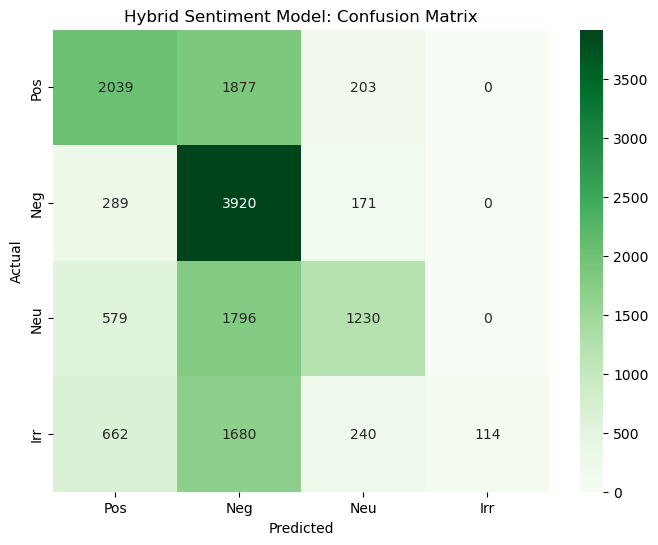


Detailed Performance Report:
              precision    recall  f1-score   support

  Irrelevant       1.00      0.04      0.08      2696
    Negative       0.42      0.89      0.57      4380
     Neutral       0.67      0.34      0.45      3605
    Positive       0.57      0.50      0.53      4119

    accuracy                           0.49     14800
   macro avg       0.67      0.44      0.41     14800
weighted avg       0.63      0.49      0.44     14800



In [16]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pos', 'Neg', 'Neu', 'Irr'], 
            yticklabels=['Pos', 'Neg', 'Neu', 'Irr'])
plt.title('Hybrid Sentiment Model: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

This approach combines different types of features to improve how the model understands text. It uses feature fusion to bring together high dimensional TF-IDF data, which captures word importance, with a simpler sentiment indicator called a lexicon polarity score. By adding this lexicon score as an extra feature, the Random Forest model receives a broader emotional context that helps it interpret text more effectively. This is especially useful for solving the cold start problem in NLP, where rare words or slang may not appear often enough in the training data for the model to learn their sentiment on its own.